In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/paysim_transaction_enriched.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,...,customer_age,customer_gender,account_age_days,is_new_account,device_type,channel,is_international,account_txn_count_30d,merchant_category,customer_state
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,...,43,Male,1531,0,Mobile,Web,0,3,Electronics,Punjab
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,...,36,Male,895,0,Tablet,App,0,16,Retail,Uttar Pradesh
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,...,41,Male,37,1,Mobile,App,0,5,Travel,Maharashtra
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,...,22,Female,52,1,Mobile,App,0,1,Gambling,Delhi
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,...,45,Male,887,0,Mobile,Web,0,1,Food,Odisha


In [3]:
df.shape

(6362620, 24)

In [4]:
# renaming columns name for readability
df = df.rename(columns={
    "nameOrig": "sender_acc",
    "nameDest": "receiver_acc",
    "oldbalanceOrg": "sender_old_balance",
    "newbalanceOrig": "sender_new_balance",
    "oldbalanceDest": "receiver_old_balance",
    "newbalanceDest": "receiver_new_balance",
    "isFraud": "is_fraud",
    "isFlaggedFraud": "is_flagged_fraud"
})

In [5]:
df.head()

,step,type,amount,sender_acc,sender_old_balance,sender_new_balance,receiver_acc,receiver_old_balance,receiver_new_balance,is_fraud,...,customer_age,customer_gender,account_age_days,is_new_account,device_type,channel,is_international,account_txn_count_30d,merchant_category,customer_state
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,...,43,Male,1531,0,Mobile,Web,0,3,Electronics,Punjab
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,...,36,Male,895,0,Tablet,App,0,16,Retail,Uttar Pradesh
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,...,41,Male,37,1,Mobile,App,0,5,Travel,Maharashtra
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,...,22,Female,52,1,Mobile,App,0,1,Gambling,Delhi
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,...,45,Male,887,0,Mobile,Web,0,1,Food,Odisha


In [6]:
# check for nulls
df.isnull().sum()

step                       0
type                       0
amount                     0
sender_acc                 0
sender_old_balance         0
sender_new_balance         0
receiver_acc               0
receiver_old_balance       0
receiver_new_balance       0
is_fraud                   0
is_flagged_fraud           0
transaction_hour           0
transaction_day_of_week    0
time_of_day                0
customer_age               0
customer_gender            0
account_age_days           0
is_new_account             0
device_type                0
channel                    0
is_international           0
account_txn_count_30d      0
merchant_category          0
customer_state             0
dtype: int64

In [7]:
# check data types of all columns 
df.dtypes

step                         int64
type                        object
amount                     float64
sender_acc                  object
sender_old_balance         float64
sender_new_balance         float64
receiver_acc                object
receiver_old_balance       float64
receiver_new_balance       float64
is_fraud                     int64
is_flagged_fraud             int64
transaction_hour             int64
transaction_day_of_week      int64
time_of_day                 object
customer_age                 int64
customer_gender             object
account_age_days             int64
is_new_account               int64
device_type                 object
channel                     object
is_international             int64
account_txn_count_30d        int64
merchant_category           object
customer_state              object
dtype: object

In [8]:
# check for duplicates 
df.duplicated().sum()

np.int64(0)

### EDA 

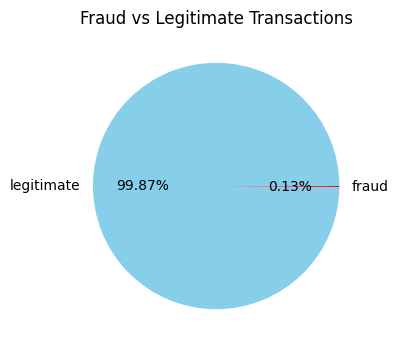

is_fraud
0    6354407
1       8213
Name: count, dtype: int64


In [9]:
# Q1. What is the overall fraud rate in the dataset?

fraud_count = df["is_fraud"].value_counts().sort_index()
labels = ["legitimate", "fraud"]
colors = ["skyblue", "red"]

plt.figure(figsize = (10,4))
plt.pie(x = fraud_count,labels = labels,colors = colors, autopct = "%1.2f%%")
plt.title("Fraud vs Legitimate Transactions")
plt.show()

print(fraud_count)

### Insights:
- Most transactions are legitimate (`99.87%`), while fraud cases are very rare (`0.13%`).
- The dataset is highly imbalanced toward non-fraud transactions.

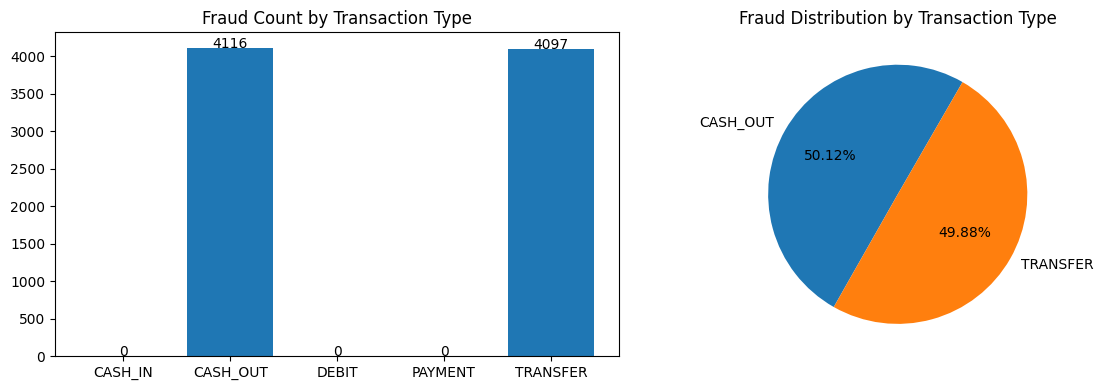

In [10]:
# Q2. Which transaction types have the highest fraud count and fraud rate?

fraud_count = df.groupby("type")["is_fraud"].sum()

plt.figure(figsize = (12,4))
plt.subplot(1,2,1)
bars = plt.bar(x = fraud_count.index,height = fraud_count.values)
plt.title("Fraud Count by Transaction Type")
# values on bars
for bar in bars:
    plt.text(
        x = bar.get_x() + bar.get_width()/2,
        y = bar.get_height(),
        s = int(bar.get_height()),
        ha = "center"
    )

plt.subplot(1,2,2)
fraud_count = fraud_count[fraud_count > 0]
plt.pie(x = fraud_count,labels = fraud_count.index,autopct = "%1.2f%%", startangle = 60)
plt.title("Fraud Distribution by Transaction Type")
plt.tight_layout()
plt.show()


### Insights:
- Fraud transactions occur only in `CASH_OUT` (4116) and `TRANSFER` (4097) transaction types.
- `CASH_OUT` contributes 50.12% and `TRANSFER` contributes 49.88% of total fraud cases.
- No fraud activity is observed in `PAYMENT`, `DEBIT`, and `CASH_IN` transactions.

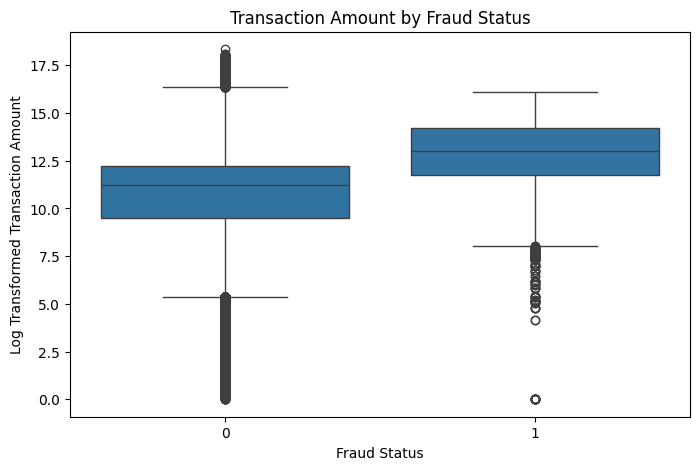

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [11]:
# Q3. How does transaction amount differ between fraud vs non-fraud?

plt.figure(figsize = (8,5))
sns.boxplot(
    data = df,
    x = "is_fraud",
    y = np.log1p(df["amount"])
)
plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Log Transformed Transaction Amount")
plt.show()

df.groupby("is_fraud")["amount"].describe()

### Insights:
- Fraud transactions generally involve higher transaction amounts than legitimate transactions.
- The median transaction amount for fraud cases (`441K`) is significantly higher than non-fraud transactions (`74K`).
- Legitimate transactions show a wider spread with transaction amounts ranging up to `92.4M`, compared to `10M` for fraud transactions.

In [12]:
# adding day_name columns based on transaction_day_of_week for better readability
day_map = {
    0: 'Monday',
    1: 'Tuesday', 
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

df['transaction_day'] = df['transaction_day_of_week'].map(day_map)

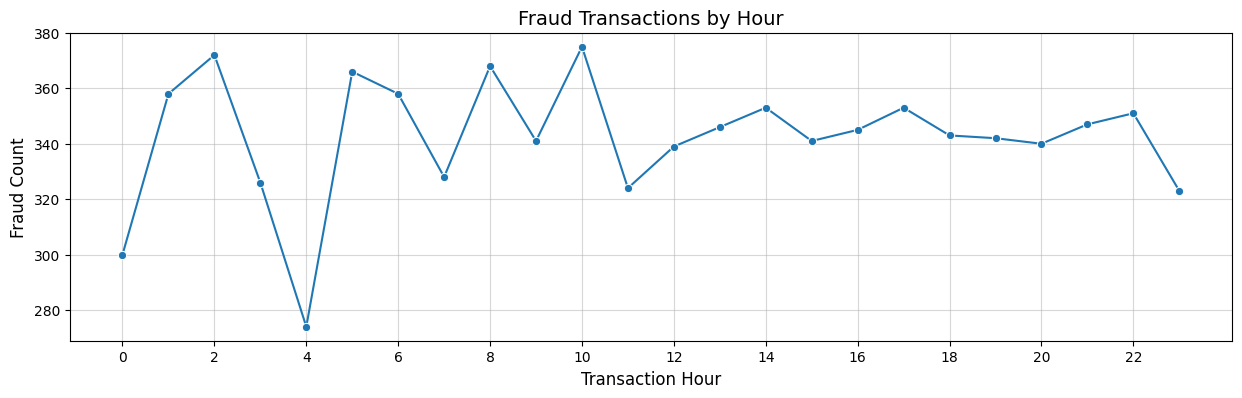

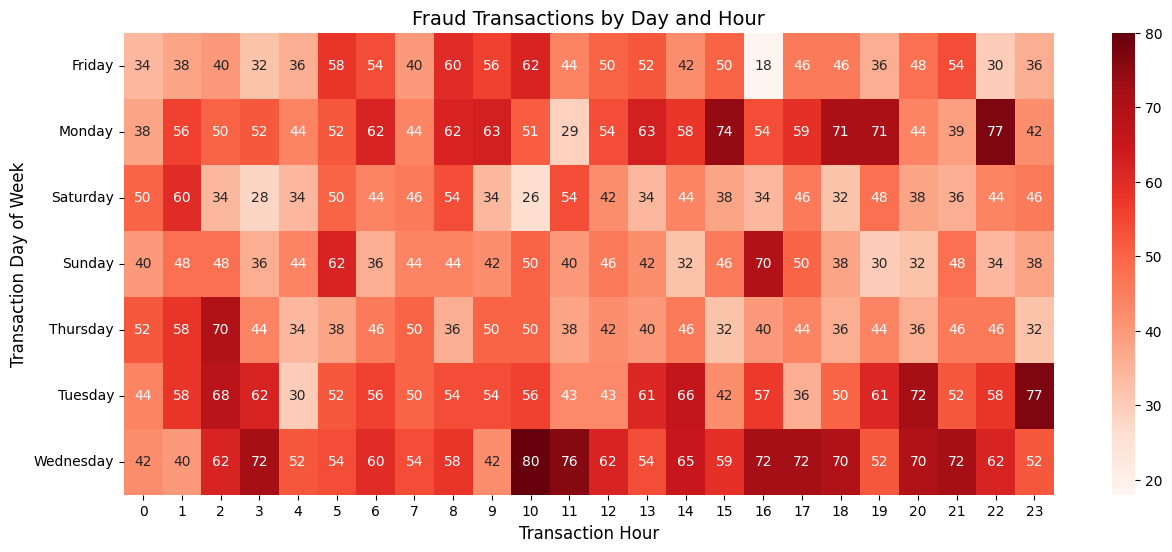

In [13]:
# Q4. At what hours and days do fraudulent transactions peak?

fraud_hours = df.groupby("transaction_hour")["is_fraud"].sum()
fraud_days =  df.pivot_table(
    values= "is_fraud",
    index = "transaction_day",
    columns="transaction_hour",
    aggfunc="sum"
)

plt.figure(figsize=(15,4))
sns.lineplot(x=fraud_hours.index,y=fraud_hours.values,marker="o")
plt.title("Fraud Transactions by Hour", fontsize=14)
plt.xlabel("Transaction Hour", fontsize=12)
plt.ylabel("Fraud Count", fontsize=12)
plt.xticks(range(0, 24, 2))
plt.grid(alpha=0.5)
plt.show()

plt.figure(figsize=(15,6))
sns.heatmap(data=fraud_days, annot=True, cmap="Reds")
plt.title("Fraud Transactions by Day and Hour", fontsize=14)
plt.xlabel("Transaction Hour", fontsize=12)
plt.ylabel("Transaction Day of Week", fontsize=12)

plt.show()

### Insights:
- Fraud transactions peak around `2 AM` and `10 AM`, where fraud counts reach approximately `370–375` transactions in the hourly trend analysis.
- The lowest fraud activity occurs near `4 AM`, with fraud counts dropping to nearly `275` transactions before rising sharply again after `5 AM`.
- The heatmap shows that fraud activity is spread across all days, with some of the highest fraud spikes occurring on `Wednesday at 10 AM` (`80` fraud cases) and late-night hours such as `Tuesday 11 PM` and `Monday 10 PM`, both reaching around `77` fraud cases.

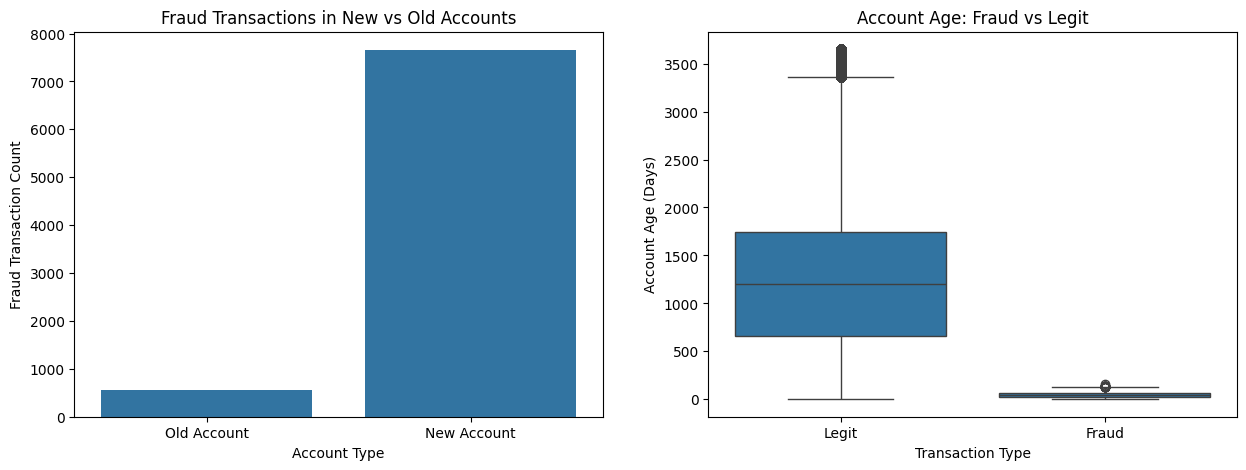

In [14]:
# Q5. Are new accounts more likely to commit fraud?

fraud_accounts = df.groupby("is_new_account")["is_fraud"].sum()
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.barplot(x=fraud_accounts.index, y=fraud_accounts.values)
plt.title("Fraud Transactions in New vs Old Accounts")
plt.xlabel("Account Type")
plt.ylabel("Fraud Transaction Count")
plt.xticks([0,1],["Old Account","New Account"])

plt.subplot(1,2,2)
sns.boxplot(x=df["is_fraud"], y=df["account_age_days"])
plt.title("Account Age: Fraud vs Legit")
plt.xlabel("Transaction Type")
plt.ylabel("Account Age (Days)")
plt.xticks([0,1], ["Legit","Fraud"])

plt.show()

### Insights:
- New accounts recorded around 7,600 fraud transactions, while old accounts had only around 500 fraud cases.
- Fraud transactions are concentrated in accounts with very low account age (median ~40–50 days).
- Legitimate transactions are associated with much older accounts, with median account age around 1,200 days.

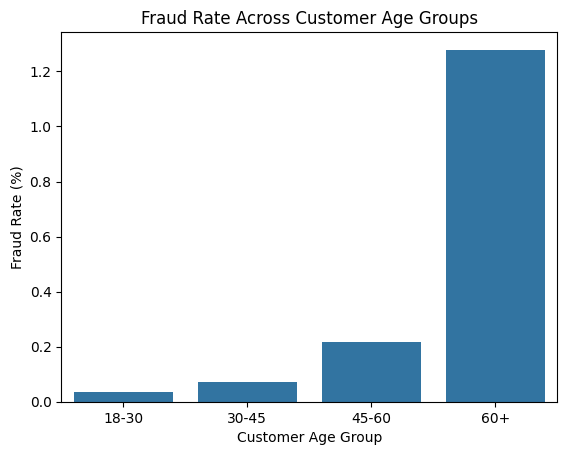

Exact Fraud Counts Across Customer Age Groups
age_group
18-30     641
30-45    2176
45-60    3124
60+      2272
Name: is_fraud, dtype: int64


In [15]:
# Q6. What is the fraud rate across customer age groups?

df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[17, 30, 45, 60, 100],
    labels=['18-30', '30-45', '45-60', '60+']
)
fraud_ages = df.groupby("age_group", observed=False)["is_fraud"].mean() * 100

sns.barplot(x=fraud_ages.index, y=fraud_ages.values)
plt.title("Fraud Rate Across Customer Age Groups")
plt.xlabel("Customer Age Group")
plt.ylabel("Fraud Rate (%)")

plt.show()

print("Exact Fraud Counts Across Customer Age Groups")
print(df.groupby("age_group", observed=False)["is_fraud"].sum())

### Insights:
- Fraud rate increases across older customer age groups.
- Customers aged 60+ show the highest fraud rate (~1.3%), while the 18–30 group has the lowest fraud rate (~0.03%).
- Fraud transaction counts are highest in the 45–60 and 60+ age groups.
- This suggests that older customers may be more vulnerable to fraudulent transactions.

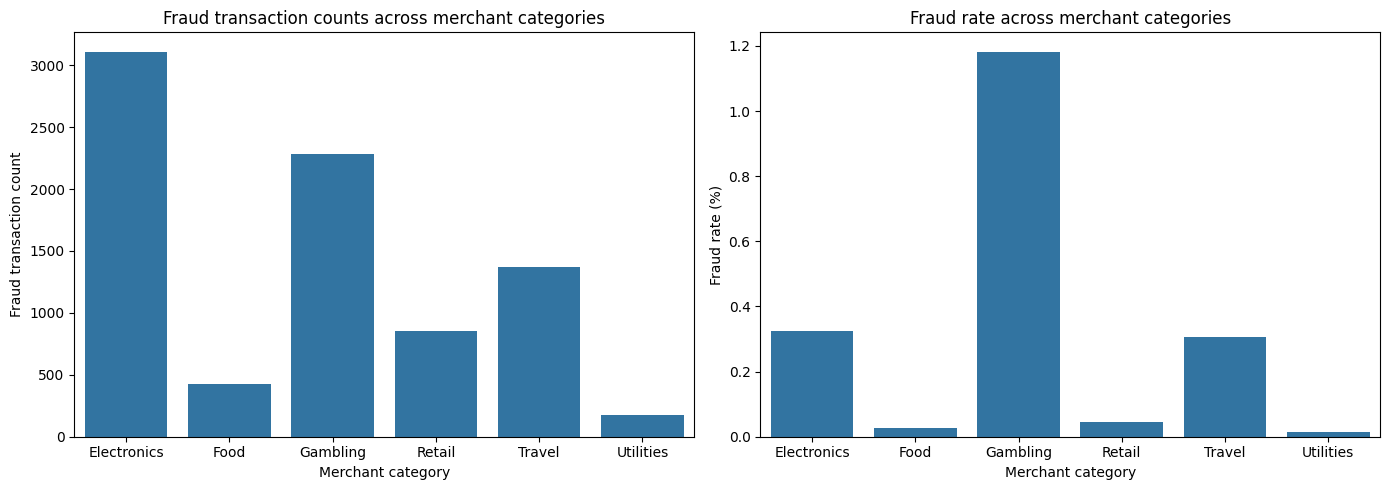

In [16]:
# Q7. Which merchant categories have the highest fraud concentration?

category_count = df.groupby("merchant_category")["is_fraud"].sum()
category_rate = df.groupby("merchant_category")["is_fraud"].mean() * 100

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.barplot(x=category_count.index,y=category_count.values)
plt.title("Fraud transaction counts across merchant categories")
plt.xlabel("Merchant category")
plt.ylabel("Fraud transaction count")

plt.subplot(1,2,2)
sns.barplot(x=category_rate.index,y=category_rate.values)
plt.title("Fraud rate across merchant categories")
plt.xlabel("Merchant category")
plt.ylabel("Fraud rate (%)")

plt.tight_layout()
plt.show()

### Insights:
- Electronics and Gambling categories recorded the highest fraud transaction counts, with around 3,100 and 2,300 fraud cases respectively.
- Gambling showed the highest fraud rate (~1.2%), followed by Electronics and Travel categories.
- Food, Retail, and Utilities categories had relatively low fraud rates and fraud transaction counts.
- This suggests that high-risk merchant categories such as Gambling and Electronics are more frequently associated with fraudulent transactions.

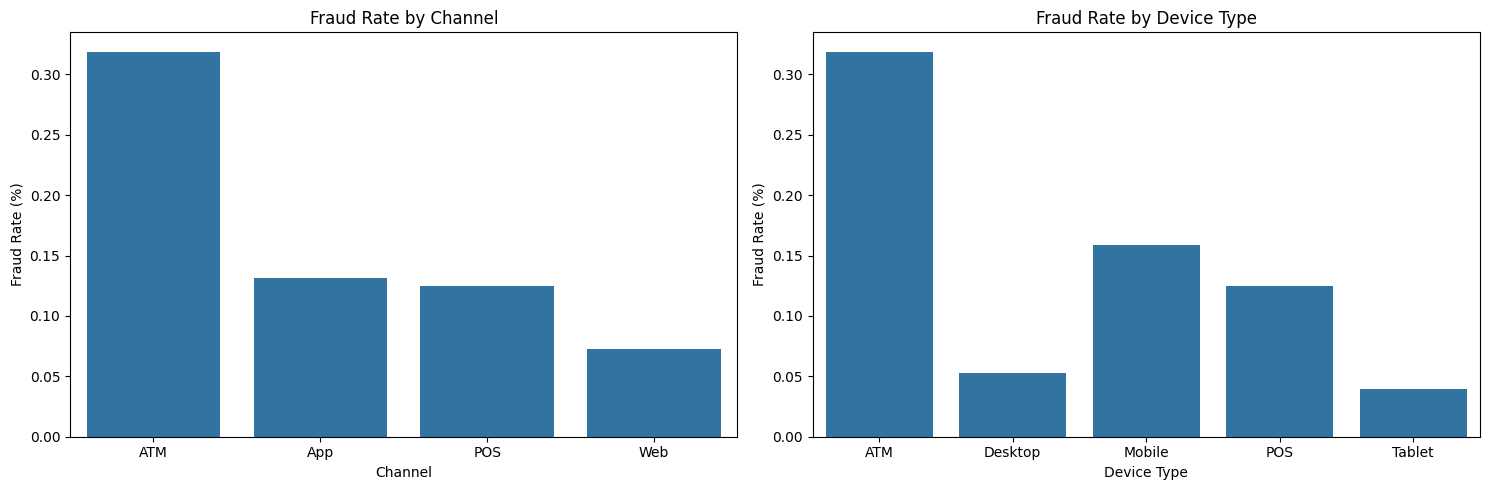

In [17]:
# Q8. Which channel and device type are most associated with fraud?

channel_rate = df.groupby("channel")["is_fraud"].mean()*100
device_rate = df.groupby("device_type")["is_fraud"].mean()*100

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.barplot(x=channel_rate.index, y=channel_rate.values)
plt.title("Fraud Rate by Channel")
plt.xlabel("Channel")
plt.ylabel("Fraud Rate (%)")

plt.subplot(1,2,2)
sns.barplot(x=device_rate.index, y=device_rate.values)
plt.title("Fraud Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

### Insights:

- ATM channel and ATM devices have the highest fraud rate at approximately **0.32%**, indicating fraud is heavily concentrated in ATM transactions.
- Mobile devices show moderate fraud activity at around **0.16%**, while Web, Desktop, and Tablet have the lowest fraud rates.
- Overall, physical transaction channels are more fraud-prone compared to online platforms.

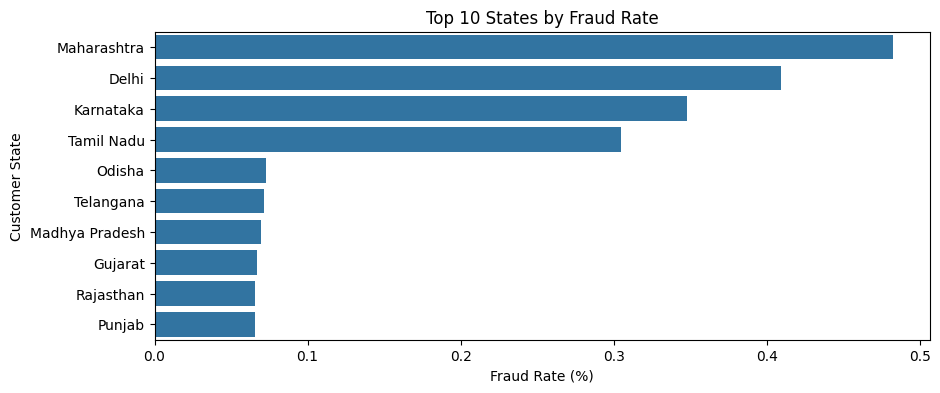

In [18]:
# Q9. Which states have the highest fraud rate? (top 10 states)
state_fraud_rate = (df.groupby("customer_state")["is_fraud"].mean() * 100).sort_values(ascending=False)

plt.figure(figsize=(10,4))
sns.barplot(x=state_fraud_rate.head(10).values, y=state_fraud_rate.head(10).index)
plt.title("Top 10 States by Fraud Rate")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Customer State")

plt.show()

### Insights:

- Maharashtra has the highest fraud rate at approximately **0.48%**, followed by Delhi (**0.41%**) and Karnataka (**0.35%**).
- Tamil Nadu also shows relatively high fraud activity with a fraud rate close to **0.30%**.
- States like Punjab, Rajasthan, and Gujarat have the lowest fraud rates among the top 10 states, all below **0.10%**.

---
---

In [19]:
df.to_csv('../data/paysim_cleaned.csv', index=False)
print("Saved as paysim_cleaned.csv")

Saved as paysim_cleaned.csv


---
---
---